In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

matches = pd.read_csv("matches.csv")

Saving matches.csv to matches.csv


In [ ]:
print(matches.shape)

(1095, 20)


In [ ]:
print(matches.columns)

Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


In [ ]:
print(matches.isnull().sum())

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64


In [ ]:
matches_per_season = matches['season'].value_counts().sort_index()
print(matches_per_season)

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


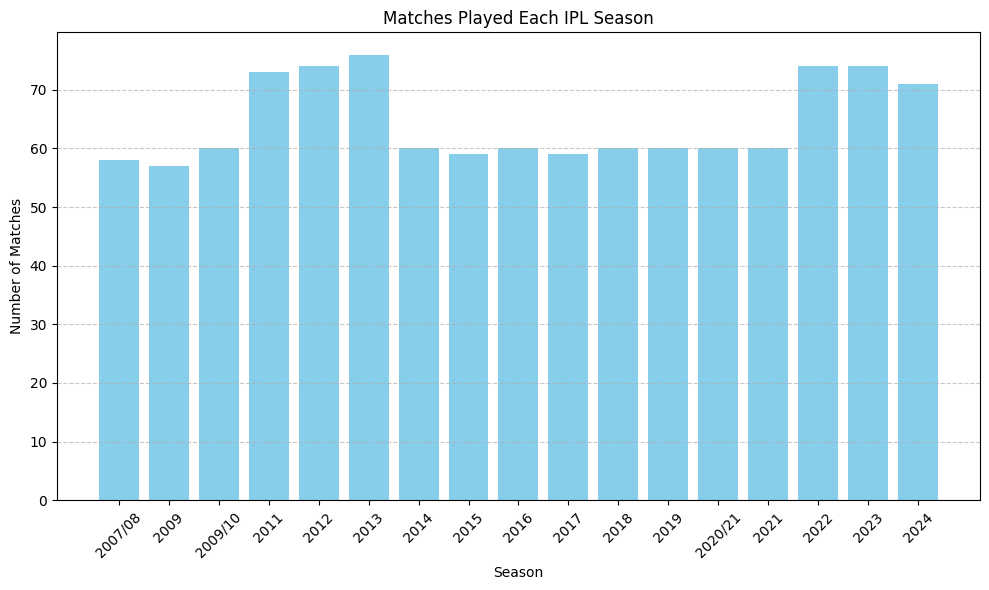

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(matches_per_season.index, matches_per_season.values,color='skyblue')
plt.title("Matches Played Each IPL Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(matches_per_season.index, rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
matches['winner'] = matches['winner'].replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bengalore': 'Royal Challengers Bangalore',
    'Gujarat Lions': 'Gujarat Titans',
    'Kings XI Punjab': 'Punjab Kings'
})

In [ ]:
team_wins = matches['winner'].value_counts()

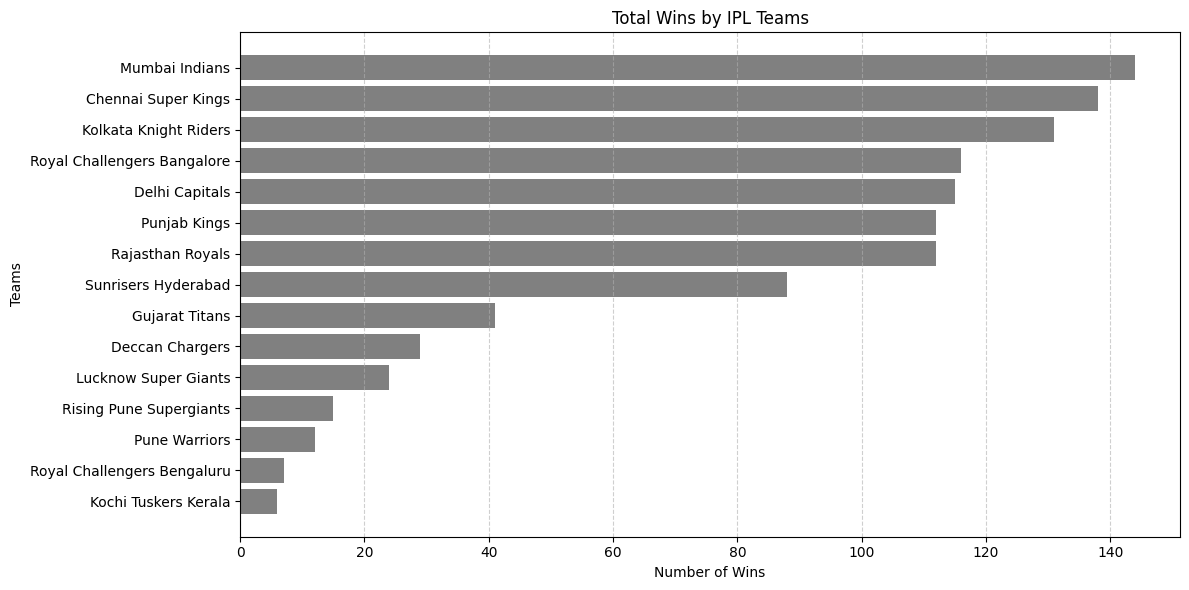

In [ ]:
plt.figure(figsize=(12, 6))
plt.barh(team_wins.index, team_wins.values, color='grey')
plt.title("Total Wins by IPL Teams")
plt.xlabel("Number of Wins")
plt.ylabel("Teams")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()

In [ ]:
top5 = matches['player_of_match'].value_counts().head(5)

Text(0.5, 1.0, 'Top 5 Player of the Match Winners')

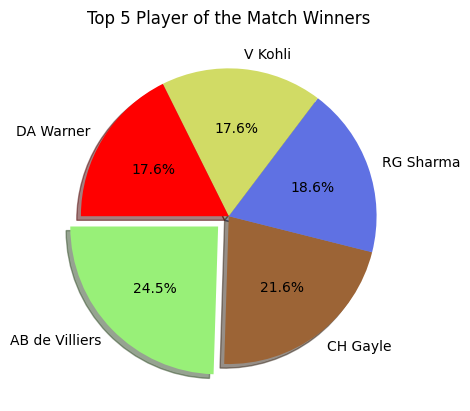

In [ ]:
import matplotlib.pyplot as plt
colors = ['#98f078','#9c6436','#5f71e3','#d1db65','red']
plt.pie(
    top5.values,
    colors=colors,
    labels=top5.index,         # labels on slices
    autopct='%1.1f%%',          # show percentage
    explode = [0.1,0,0,0,0],
    shadow = True,
    startangle=180
)
plt.title("Top 5 Player of the Match Winners")

In [ ]:
matches['toss_match_same'] = matches['toss_winner'] == matches['winner']

In [ ]:
result = matches['toss_match_same'].value_counts()
print(result)

toss_match_same
False    627
True     468
Name: count, dtype: int64


In [ ]:
total = result.sum()
win_percent = (result[True] / total) * 100
print(f"Toss winner also won match in {win_percent:.2f}% cases")

Toss winner also won match in 42.74% cases


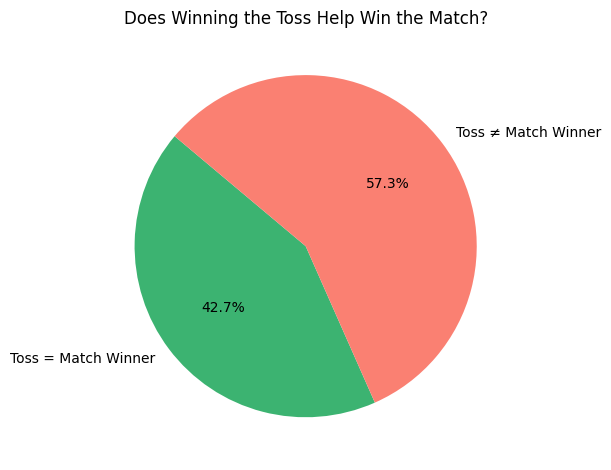

In [ ]:
import matplotlib.pyplot as plt

labels = ['Toss = Match Winner', 'Toss ≠ Match Winner']
values = [result[True], result[False]]
colors = ['mediumseagreen', 'salmon']

plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title("Does Winning the Toss Help Win the Match?")
plt.tight_layout()

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

deliveries = pd.read_csv("deliveries.csv")

Saving deliveries.csv to deliveries.csv


In [22]:
print(deliveries.shape[0])


260920


In [23]:
deliveries = deliveries.dropna(subset=['dismissal_kind'])

In [24]:
valid_dismissals = ['bowled', 'caught', 'lbw', 'stumped', 'caught and bowled', 'hit wicket']
deliveries = deliveries[deliveries['dismissal_kind'].isin(valid_dismissals)]

In [25]:
wicket_counts = deliveries['bowler'].value_counts().head(10)

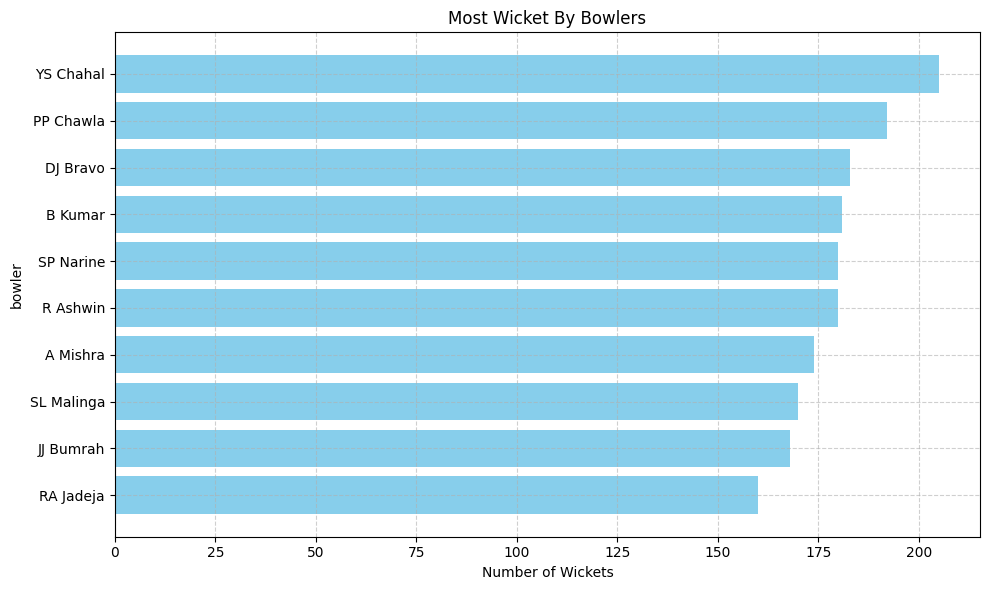

In [26]:
plt.figure(figsize=(10, 6))
plt.barh(wicket_counts.index,wicket_counts.values, color='skyblue')
plt.title("Most Wicket By Bowlers")
plt.xlabel("Number of Wickets")
plt.ylabel("bowler")
plt.grid( linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()

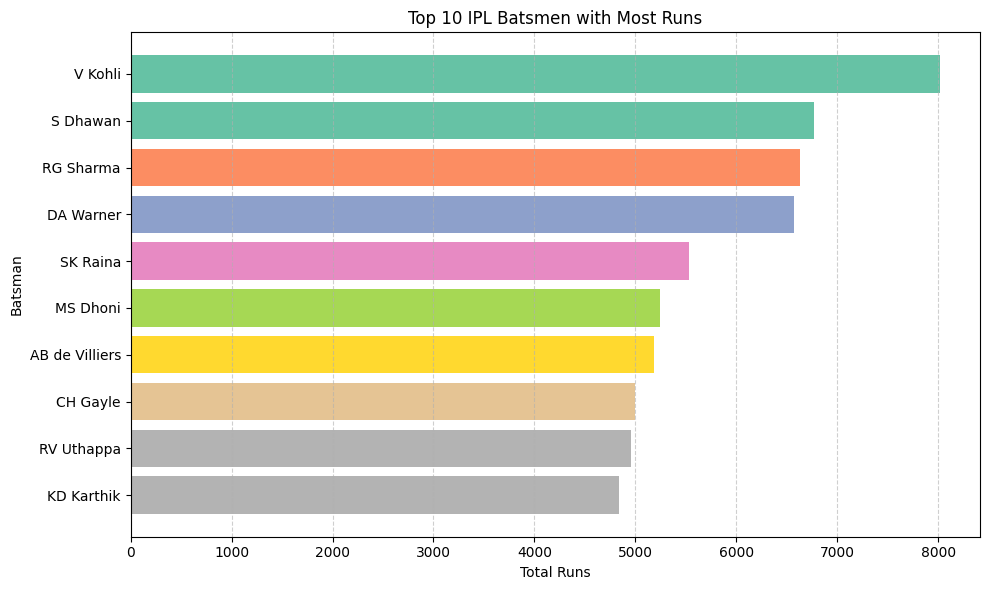

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

deliveries = pd.read_csv("deliveries.csv")
batter_runs = deliveries.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, 10))

plt.barh(batter_runs.index, batter_runs.values, color=colors)
plt.title("Top 10 IPL Batsmen with Most Runs")
plt.xlabel("Total Runs")
plt.ylabel("Batsman")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()